### Unzip The Dataset


In [ ]:
# !unzip "/content/drive/MyDrive/fake_and_real_images/Dataset/archive (2).zip" -d"/content/drive/MyDrive/fake_and_real_images"

# Balanced The Dataset

In [ ]:
import os
import random
import shutil
from tqdm import tqdm

random.seed(42)

SOURCE_DIR = "/content/drive/MyDrive/fake_and_real_images/Data"
OUTPUT_DIR = "/content/Dataset_2k"   # LOCAL ONLY
SAMPLES_PER_CLASS = 1000

os.makedirs(OUTPUT_DIR, exist_ok=True)

for label in ["Real", "Fake"]:
    src = os.path.join(SOURCE_DIR, label)
    dst = os.path.join(OUTPUT_DIR, label)
    os.makedirs(dst, exist_ok=True)

    images = [f for f in os.listdir(src) if f.lower().endswith(".jpg")]
    assert len(images) >= SAMPLES_PER_CLASS, f"Not enough images in {label}"

    selected = random.sample(images, SAMPLES_PER_CLASS)

    print(f"Copying {label} images...")
    for img in tqdm(selected, desc=label):
        shutil.copyfile(
            os.path.join(src, img),
            os.path.join(dst, img)
        )

    print(f"{label}: {len(selected)} images copied")


Copying Real images...


Real: 100%|██████████| 1000/1000 [01:20<00:00, 12.40it/s]


Real: 1000 images copied
Copying Fake images...


Fake: 100%|██████████| 1000/1000 [05:45<00:00,  2.89it/s]


Fake: 1000 images copied


# Re-Structure The Dataset

In [ ]:
import os
import random
import shutil
from tqdm import tqdm

random.seed(42)

SRC = "/content/Dataset_2k"        # LOCAL
DST = "/content/dataset_final_2"     # LOCAL

SPLITS = {"train": 0.7, "val": 0.15, "test": 0.15}
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png")

def split_class(cls):
    src_dir = os.path.join(SRC, cls)

    files = [
        f for f in os.listdir(src_dir)
        if f.lower().endswith(IMG_EXTENSIONS)
    ]

    random.shuffle(files)

    n = len(files)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)

    split_map = {
        "train": files[:n_train],
        "val": files[n_train:n_train + n_val],
        "test": files[n_train + n_val:]
    }

    for split, imgs in split_map.items():
        out_dir = os.path.join(DST, split, cls)
        os.makedirs(out_dir, exist_ok=True)

        for img in tqdm(imgs, desc=f"{cls} → {split}", leave=False):
            shutil.copyfile(
                os.path.join(src_dir, img),
                os.path.join(out_dir, img)
            )

for cls in ["Real", "Fake"]:
    split_class(cls)

print("✅ Fast, leak-safe split completed (local disk).")


✅ Fast, leak-safe split completed (local disk).


In [ ]:
for split in ["train", "val", "test"]:
    for cls in ["Real", "Fake"]:
        p = f"/content/dataset_final_2/{split}/{cls}"
        print(split, cls, len(os.listdir(p)))


train Real 700
train Fake 700
val Real 150
val Fake 150
test Real 150
test Fake 150


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Libraries

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
import pandas as pd
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

## UsIng Fast Fourier Transform(FFT) Features

In [ ]:
def fft_feature(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    mag = np.log(np.abs(fshift) + 1)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return mag.astype(np.uint8)


### Using RGB+FFT for Dataset

In [ ]:
class RGBFFT_Dataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.transform = transform

        class_map = {"Fake": 0, "Real": 1}

        for cls, label in class_map.items():
            cls_path = os.path.join(root, cls)
            for f in os.listdir(cls_path):
                self.samples.append((os.path.join(cls_path, f), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        rgb = np.array(Image.open(path).convert("RGB"))
        fft = fft_feature(rgb)

        rgb = Image.fromarray(rgb)
        fft = Image.fromarray(fft).convert("RGB")

        if self.transform:
            rgb = self.transform(rgb)
            fft = self.transform(fft)

        x = torch.cat([rgb, fft], dim=0)  # (6, H, W)
        return x, label


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


# Loading The Train,Val,Test Data

In [ ]:
import torch.nn as nn
from torchvision import models
train_ds = RGBFFT_Dataset("/content/drive/MyDrive/fake_and_real_images/Dataset_2/train", transform)
val_ds   = RGBFFT_Dataset("/content/drive/MyDrive/fake_and_real_images/Dataset_2/val", transform)
test_ds  = RGBFFT_Dataset("/content/drive/MyDrive/fake_and_real_images/Dataset_2/test", transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

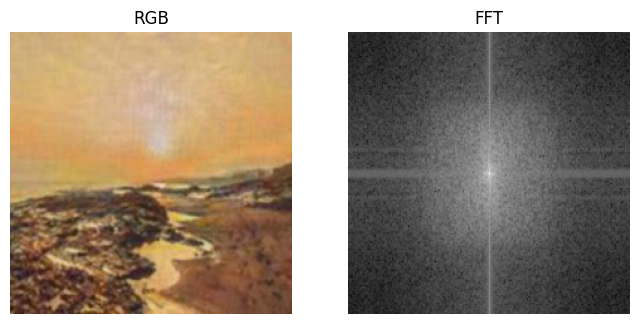

In [ ]:
import matplotlib.pyplot as plt

x, y = train_ds[10]

rgb = x[:3].permute(1, 2, 0)
fft = x[3:].mean(0)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(fft, cmap="gray")
plt.title("FFT")
plt.axis("off")
plt.show()


# Using Vision Tranformer Model(VIT)

In [ ]:
class RGBFFT_ViT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            in_chans=6,     # RGB + FFT
            num_classes=0
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)


### Training Code For Vit Model

In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import timm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RGBFFT_ViT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)  # ViT needs lower LR

epochs = 15

for epoch in range(epochs):
    # ---- TRAIN ----
    model.train()
    train_loss = 0

    for x, y in tqdm(train_loader, desc=f"ViT Train {epoch+1}/{epochs}"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- VALIDATION ----
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc=f"ViT Val {epoch+1}/{epochs}"):
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    print(f"[ViT] Epoch {epoch+1} | Loss {train_loss:.4f} | Val Acc {val_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
ViT Val 1/15: 100%|██████████| 5/5 [00:06<00:00,  1.37s/it]


[ViT] Epoch 1 | Loss 0.5434 | Val Acc 0.8533


ViT Val 2/15: 100%|██████████| 5/5 [00:07<00:00,  1.45s/it]


[ViT] Epoch 2 | Loss 0.2214 | Val Acc 0.9633


ViT Val 3/15: 100%|██████████| 5/5 [00:06<00:00,  1.31s/it]


...

[ViT] Epoch 13 | Loss 0.0075 | Val Acc 0.9867


ViT Val 14/15: 100%|██████████| 5/5 [00:06<00:00,  1.24s/it]


[ViT] Epoch 14 | Loss 0.0042 | Val Acc 0.9800


ViT Val 15/15: 100%|██████████| 5/5 [00:06<00:00,  1.26s/it]

[ViT] Epoch 15 | Loss 0.0021 | Val Acc 0.9900


In [ ]:
torch.save({
    "model_state": model.state_dict(),
    "class_names": ["Fake", "Real"]
}, "/content/drive/MyDrive/fake_and_real_images/Vision_Transformer_Model.pth")


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1]  # probability of class "Fake"
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print(f"✅ Test Accuracy   : {accuracy:.4f}")
print(f"✅ Test Precision  : {precision:.4f}")
print(f"✅ Test Recall     : {recall:.4f}")
print(f"✅ Test F1-score   : {f1:.4f}")
print(f"✅ Test AUC        : {auc:.4f}")


✅ Test Accuracy   : 0.9867
✅ Test Precision  : 0.9740
✅ Test Recall     : 1.0000
✅ Test F1-score   : 0.9868
✅ Test AUC        : 1.0000


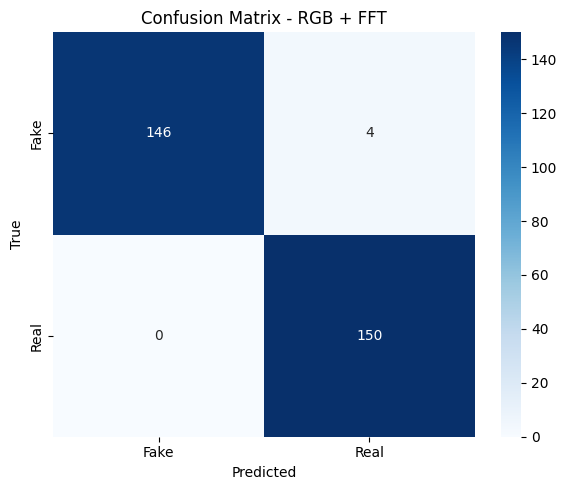

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - RGB + FFT")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Real", "Fake"],
        digits=4
    )
)


              precision    recall  f1-score   support

        Real     1.0000    0.9733    0.9865       150
        Fake     0.9740    1.0000    0.9868       150

    accuracy                         0.9867       300
   macro avg     0.9870    0.9867    0.9867       300
weighted avg     0.9870    0.9867    0.9867       300



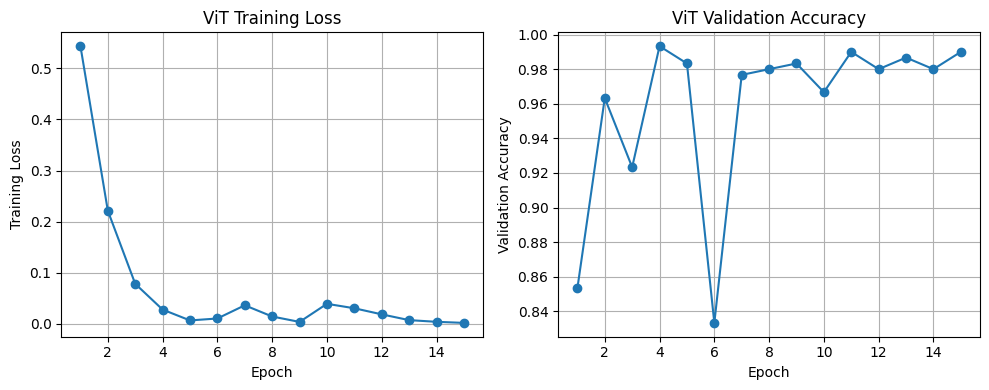

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 16))

# Training Loss (from your logs)
train_loss = [
    0.5434, 0.2214, 0.0785, 0.0281, 0.0069,
    0.0107, 0.0365, 0.0146, 0.0040, 0.0394,
    0.0307, 0.0188, 0.0075, 0.0042, 0.0021
]

# Validation Accuracy (from your logs)
val_acc = [
    0.8533, 0.9633, 0.9233, 0.9933, 0.9833,
    0.8333, 0.9767, 0.9800, 0.9833, 0.9667,
    0.9900, 0.9800, 0.9867, 0.9800, 0.9900
]

# ---- Plot ----
plt.figure(figsize=(10, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("ViT Training Loss")
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, val_acc, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ViT Validation Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


### Prediction

In [ ]:
# ===================== IMPORTS =====================
import cv2
import torch
import timm
import numpy as np
from PIL import Image
import torch.nn as nn
from torchvision import transforms

# ===================== DEVICE =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== FFT FUNCTION =====================
def fft_feature(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    mag = np.log(np.abs(fshift) + 1)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return mag.astype(np.uint8)

# ===================== TRANSFORMS =====================
# Step 1: basic transform for RGB and FFT separately (3 channels each)
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Step 2: normalize AFTER concatenation (6 channels)
normalize_6ch = transforms.Normalize(
    mean=[0.485, 0.485, 0.485, 0.485, 0.485, 0.485],
    std=[0.229, 0.229, 0.229, 0.229, 0.229, 0.229]
)

# ===================== MODEL =====================
class RGBFFT_ViT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=False,   # MUST be False when loading your checkpoint
            in_chans=6,
            num_classes=0
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)

# ===================== LOAD MODEL =====================
model = RGBFFT_ViT(num_classes=2).to(device)

checkpoint = torch.load(
    "/content/drive/MyDrive/fake_and_real_images/Vision_Transformer_Model.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

print("✅ Model loaded successfully")

# ===================== PREDICTION FUNCTION =====================
def predict_image(image_path):
    model.eval()

    # Load RGB image
    rgb_np = np.array(Image.open(image_path).convert("RGB"))

    # FFT image
    fft_np = fft_feature(rgb_np)

    # Convert to PIL
    rgb_pil = Image.fromarray(rgb_np)
    fft_pil = Image.fromarray(fft_np).convert("RGB")

    # Apply base transform (3ch + 3ch)
    rgb = base_transform(rgb_pil)
    fft = base_transform(fft_pil)

    # Concatenate -> (6, 224, 224)
    x = torch.cat([rgb, fft], dim=0)

    # Normalize AFTER concat
    x = normalize_6ch(x)

    # Add batch dimension
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    classes = ["Fake", "Real"]

    return {
        "prediction": classes[pred],
        "confidence": probs[0, pred].item()
    }

# ===================== TEST =====================
result = predict_image(
    "/content/drive/MyDrive/fake_and_real_images/Dataset_2/train/Real/000d655562800587aceb35c35ed4c47cc.jpg"
)

print("Prediction :", result["prediction"])
print("Confidence :", round(result["confidence"] * 100, 2), "%")


✅ Model loaded successfully
Prediction : Real
Confidence : 99.92 %
